<a href="https://colab.research.google.com/github/yizharf9/coding/blob/feature_branch/bgu/gen_models/orthogonal_diff/gen_mod_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/My Drive/University/My_Docs/Fourth year/Generative Models/project"

Mounted at /content/drive


In [ ]:
# Install Python libraries

# 1. Install objaverse, trimesh, and pyrender first. This will install PyOpenGL==3.1.0.
!pip install objaverse trimesh pyrender

# 2. Re-install PyOpenGL==3.1.0 just to be sure it's correctly set up.
#    Removed PyOpenGL_accelerate installation as it's causing build errors and is often optional.
#!pip install --force-reinstall PyOpenGL==3.1.0
!pip install --force-reinstall PyOpenGL

# Install system drivers for "Headless" (no screen) rendering
!apt-get update
!apt-get install -y libgl1-mesa-glx libosmesa6

# Install the magic library for streaming zips
!pip install remotezip

  Using cached PyOpenGL-3.1.0-py3-none-any.whl
  Attempting uninstall: PyOpenGL
    Found existing installation: PyOpenGL 3.1.10
    Uninstalling PyOpenGL-3.1.10:
      Successfully uninstalled PyOpenGL-3.1.10
  Using cached pyopengl-3.1.10-py3-none-any.whl.metadata (3.3 kB)
Using cached pyopengl-3.1.10-py3-none-any.whl (3.2 MB)
  Attempting uninstall: PyOpenGL
    Found existing installation: PyOpenGL 3.1.0
    Uninstalling PyOpenGL-3.1.0:
      Successfully uninstalled PyOpenGL-3.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyrender 0.1.45 requires PyOpenGL==3.1.0, but you have pyopengl 3.1.10 which is incompatible.
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 ht

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
# prompt = "monkey on a stick"
# image = pipe(prompt).images[0]
# image_path = f"{folder_path}/images"
# image.save(f"{image_path}/test_image.png")
# print("Image generated successfully!")

In [ ]:
import os
# "osmesa" is CRITICAL for Colab to render 3D without a monitor
os.environ["PYOPENGL_PLATFORM"] = "osmesa"

import trimesh
import pyrender
import numpy as np
from PIL import Image
from remotezip import RemoteZip
import io
import shutil

# --- CONFIGURATION ---
# The URL to the MASSIVE zip file
ZIP_URL = "https://3dcompat-dataset.s3-us-west-1.amazonaws.com/v2/3D_ZIP/3DCoMPaT_ZIP.zip"

OUTPUT_DIR = "./dataset_3dcompat_small"
RESOLUTION = 512
TARGET_COUNT = 50  # We only want this many objects

# Create output folder
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries installed and configuration set.")

Libraries installed and configuration set.


In [ ]:
# --- 1. HELPER: CENTER & SCALE MESH (SIMPLIFIED) ---
def normalize_scene(mesh):
    if hasattr(mesh, 'bounds') and mesh.bounds is not None:
        # 1. Center the mesh at (0,0,0)
        center = mesh.bounds.mean(axis=0)
        mesh.apply_translation(-center)

        # 2. Scale to fit in a unit sphere
        # We use a safe scale factor (0.6) to guarantee it fits in the camera frame
        scale = 0.6 / np.max(mesh.extents)
        mesh.apply_scale(scale)

        # --- REMOVED ROTATION ---
        # We removed the -90 degree rotation.
        # This fixes the "Upside Down" and "View from Above" issues
        # for objects that were already correct.
    else:
        return None
    return mesh

# --- 2. HELPER: RENDER 4 VIEWS (FIXED CAMERA) ---
def render_four_views(mesh_path):
    try:
        mesh = trimesh.load(mesh_path, force='mesh')
    except Exception as e:
        print(f"  -> Load Error: {e}")
        return None

    if isinstance(mesh, trimesh.Scene):
        if len(mesh.geometry) == 0: return None
        mesh = trimesh.util.concatenate(tuple(mesh.geometry.values()))

    mesh = normalize_scene(mesh)
    if mesh is None: return None

    # Visual Fixes
    if mesh.visual and (mesh.visual.kind == 'texture' or mesh.visual.kind == 'material'):
        try:
            mesh.visual = mesh.visual.to_color()
        except:
            mesh.visual = trimesh.visual.ColorVisuals(face_colors=[200, 200, 200, 255])
    elif not mesh.has_visual:
        mesh.visual = trimesh.visual.ColorVisuals(face_colors=[200, 200, 200, 255])

    try:
        mesh_pr = pyrender.Mesh.from_trimesh(mesh)
    except:
        return None

    scene = pyrender.Scene(bg_color=[255, 255, 255])
    scene.add(mesh_pr)

    camera = pyrender.PerspectiveCamera(yfov=np.pi / 3.0, aspectRatio=1.0)

    # --- FIX 1: INCREASED DISTANCE (Fixes Missing Front) ---
    dist = 1.0
    height = 0.0

    # [Front, Right, Back, Left]
    cam_positions = [
        [0,    height, dist],  # Front
        [dist, height, 0],     # Right
        [0,    height, -dist], # Back
        [-dist, height, 0]     # Left
    ]

    views = []
    r = pyrender.OffscreenRenderer(viewport_width=RESOLUTION//2, viewport_height=RESOLUTION//2)

    for pos in cam_positions:
        cam_pos = np.array(pos)

        # --- FIX 2: MANUAL LOOK-AT MATRIX (Fixes Upside Down) ---
        # We strictly define the axes to prevent camera rolling.
        # Forward: Points from Camera to Origin
        forward = -cam_pos / np.linalg.norm(cam_pos)

        # Up: Global Y-Axis (0, 1, 0)
        global_up = np.array([0, 1, 0])

        # Right: Cross product of Forward and Up
        right = np.cross(global_up, forward)
        # Handle the edge case where looking straight down/up
        if np.linalg.norm(right) < 0.001:
            right = np.array([1, 0, 0])
        right = right / np.linalg.norm(right)

        # Recalculate Up (to be orthogonal)
        up = np.cross(forward, right)

        # Construct the 4x4 Transformation Matrix
        pose = np.eye(4)
        pose[:3, 0] = right   # X-axis
        pose[:3, 1] = -up      # Y-axis
        pose[:3, 2] = -forward # Z-axis (Camera looks down -Z)
        pose[:3, 3] = cam_pos # Position

        cam_node = scene.add(camera, pose=pose)

        # Light follows camera
        light = pyrender.DirectionalLight(color=[1.0, 1.0, 1.0], intensity=5.0)
        light_node = scene.add(light, pose=pose)

        try:
            color, depth = r.render(scene)
            views.append(Image.fromarray(color))
        except:
            print("Error with insert to views.")

        scene.remove_node(cam_node)
        scene.remove_node(light_node)

    r.delete()
    return views

In [ ]:
#@title  --- 3. DOWNLOAD PHASE ---
from remotezip import RemoteZip
import os
import shutil

# Configuration
RAW_DIR = "./raw_models"
TARGET_COUNT = 50  # Number of objects to download

# Clear/Create Directory
if os.path.exists(RAW_DIR):
    shutil.rmtree(RAW_DIR)
os.makedirs(RAW_DIR, exist_ok=True)

print(f"Connecting to Remote Zip...")

try:
    with RemoteZip(ZIP_URL) as z:
        print("✅ Connection established! Scanning file list...")

        # 1. Get All Files
        all_files = z.namelist()

        # 2. Filter for 3D Formats
        model_candidates = [
            f for f in all_files
            if f.lower().endswith(('.obj', '.ply', '.glb', '.gltf'))
            and "__MACOSX" not in f
        ]

        print(f"Found {len(model_candidates)} valid 3D models.")
        print(f"Downloading the first {TARGET_COUNT} models to '{RAW_DIR}'...")

        count = 0
        for member_name in model_candidates:
            if count >= TARGET_COUNT: break

            # Simple progress print
            if count % 5 == 0:
                print(f"Downloading {count+1}/{TARGET_COUNT}...", end=" ")

            try:
                # Extract to the raw directory
                z.extract(member_name, RAW_DIR)
                print("OK.")
                count += 1
            except Exception as e:
                print(f"Failed: {e}")
                continue

    print(f"\n✅ DOWNLOAD COMPLETE. {count} models are stored in '{RAW_DIR}'")

except Exception as e:
    print(f"\n❌ CONNECTION ERROR: {e}")

Connecting to Remote Zip...
✅ Connection established! Scanning file list...
Found 8753 valid 3D models.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.
OK.

✅ DOWNLOAD COMPLETE. 50 models are stored in './raw_models'


In [ ]:
#@title data processing
# --- 4. PROCESSING PHASE (Render Views) ---
import glob

# Configuration
OUTPUT_DIR = "./dataset_3dcompat_small"
RESOLUTION = 512

# Create Output Directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Find the downloaded files (recursively, because zip extracts folders)
print(f"Searching for models in {RAW_DIR}...")
found_files = []
for ext in ['*.obj', '*.ply', '*.glb', '*.gltf']:
    found_files.extend(glob.glob(f"{RAW_DIR}/**/{ext}", recursive=True))

# Filter out MacOS junk if any slipped through
found_files = [f for f in found_files if "__MACOSX" not in f]

print(f"Found {len(found_files)} models on disk. Starting Renderer...")

count = 0
for i, file_path in enumerate(found_files):
    # Derive Category & Name for the file
    # Path is usually: .../raw_models/3DCoMPaT/train/lamp/model.ply
    path_parts = file_path.split(os.sep)

    # Try to grab meaningful names
    if len(path_parts) >= 2:
        category = path_parts[-2] # Folder name (e.g., 'lamp')
        obj_id = path_parts[-1].split('.')[0] # File name (e.g., 'model')
    else:
        category = "object"
        obj_id = str(i)

    # Clean up boring names
    if category.lower() in ["models", "meshes", "train", "test"]:
        try:
            category = path_parts[-3]
        except:
            category = "object"

    print(f"[{i+1}/{len(found_files)}] Rendering {category}...", end=" ")

    # --- CALL THE RENDERER ---
    # (Uses the 'render_four_views' function you defined in Block 2)
    views = render_four_views(file_path)

    if views and len(views) == 4:
        # Stitch 2x2 Grid
        grid = Image.new('RGB', (RESOLUTION, RESOLUTION))
        grid.paste(views[0], (0, 0))               # Front
        grid.paste(views[1], (RESOLUTION//2, 0))   # Right
        grid.paste(views[2], (0, RESOLUTION//2))   # Back
        grid.paste(views[3], (RESOLUTION//2, RESOLUTION//2)) # Left

        # transpose
        grid = grid.transpose(Image.FLIP_TOP_BOTTOM)

        # Generate Safe Filename
        safe_name = f"{category}_{obj_id}_{i}".replace(" ", "_")

        # Save Image
        grid.save(f"{OUTPUT_DIR}/{safe_name}.png")

        # Save Text Caption
        with open(f"{OUTPUT_DIR}/{safe_name}.txt", "w") as f:
            f.write(f"A 3D view of a {category}")

        print("✅ Saved.")
        count += 1
    else:
        print("❌ Render Failed (Check Block 2 logic).")

print(f"\nDONE! Processed {count} images. Results are in '{OUTPUT_DIR}'")

Searching for models in ./raw_models...
Found 50 models on disk. Starting Renderer...
[1/50] Rendering raw_models... ✅ Saved.
[2/50] Rendering raw_models... ✅ Saved.
[3/50] Rendering raw_models... ✅ Saved.
[4/50] Rendering raw_models... ✅ Saved.
[5/50] Rendering raw_models... ✅ Saved.
[6/50] Rendering raw_models... ✅ Saved.
[7/50] Rendering raw_models... ✅ Saved.
[8/50] Rendering raw_models... ✅ Saved.
[9/50] Rendering raw_models... ✅ Saved.
[10/50] Rendering raw_models... ✅ Saved.
[11/50] Rendering raw_models... ✅ Saved.
[12/50] Rendering raw_models... ✅ Saved.
[13/50] Rendering raw_models... ✅ Saved.
[14/50] Rendering raw_models... ✅ Saved.
[15/50] Rendering raw_models... ✅ Saved.
[16/50] Rendering raw_models... ✅ Saved.
[17/50] Rendering raw_models... ✅ Saved.
[18/50] Rendering raw_models... ✅ Saved.
[19/50] Rendering raw_models... ✅ Saved.
[20/50] Rendering raw_models... ✅ Saved.
[21/50] Rendering raw_models... ✅ Saved.
[22/50] Rendering raw_models... ✅ Saved.
[23/50] Rendering raw

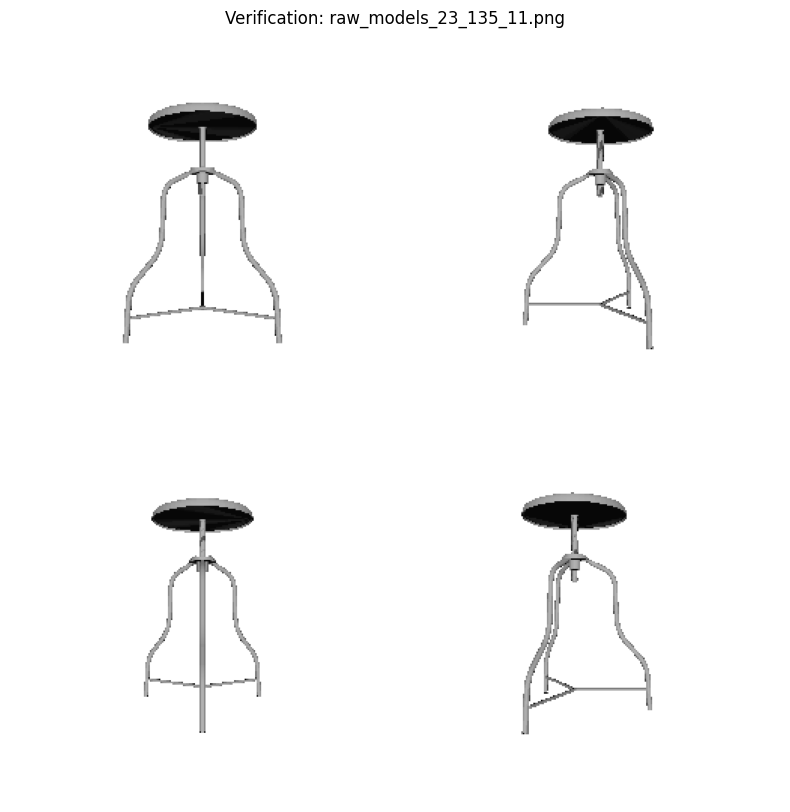

✅ Verification successful: You should see a 2x2 grid above.
   [Back] [Left]
   [Front ] [Right ]


In [ ]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

# 1. Find all generated PNGs
image_files = glob.glob(f"{OUTPUT_DIR}/*.png")

if image_files:
    # 2. Pick the first one to check
    test_image_path = image_files[49]
    img = Image.open(test_image_path)

    # 3. Display it using Matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Verification: {os.path.basename(test_image_path)}")
    plt.show()

    print("✅ Verification successful: You should see a 2x2 grid above.")
    print("   [Back] [Left]")
    print("   [Front ] [Right ]")
else:
    print("❌ No images found! The generation step might have failed.")

In [ ]:
import zipfile
import os
import glob
import shutil

# --- CONFIGURATION ---
SOURCE_DIR = './dataset_3dcompat_small'
ZIP_NAME = 'dataset_selected_new.zip'

# Ensure destination path is set (using the folder_path you defined earlier)
# If folder_path isn't defined, we default to a standard Drive path
try:
    destination = f"{folder_path}/{ZIP_NAME}"
except NameError:
    destination = f"/content/drive/My Drive/Generative_Project/{ZIP_NAME}"

# THE INDICES YOU REQUESTED
indices_to_save = [1, 2, 3, 4, 7, 14, 16, 17, 20, 21, 22, 23, 25, 26, 28, 31, 37, 38, 47, 49]

print(f"Preparing to zip specific files from {SOURCE_DIR}...")

# 1. Get all PNG files and SORT them
# Sorting is critical: without it, 'Index 1' might be a different file every time.
all_pngs = glob.glob(f"{SOURCE_DIR}/*.png")

if not all_pngs:
    print("❌ No PNG files found! Check your source directory.")
else:
    print(f"Found {len(all_pngs)} total files in directory.")

    # 2. Create the Zip
    with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zipf:
        count = 0
        for i in indices_to_save:
            # Check if the index actually exists in the list
            if 0 <= i < len(all_pngs):
                png_path = all_pngs[i]
                filename = os.path.basename(png_path)

                print(f"Zipping Index {i}: {filename}")

                # Add PNG
                zipf.write(png_path, arcname=filename)

                # Add corresponding TXT file
                txt_path = png_path.replace(".png", ".txt")
                if os.path.exists(txt_path):
                    zipf.write(txt_path, arcname=os.path.basename(txt_path))

                count += 1
            else:
                print(f"⚠️ Warning: Index {i} is out of range (max index is {len(all_pngs)-1})")

    print(f"✅ Created zip with {count} items.")

    # 3. Move to Google Drive
    print(f"Moving to {destination}...")
    try:
        shutil.move(ZIP_NAME, destination)
        print("Success! Your filtered dataset is safe in Google Drive.")
    except Exception as e:
        print(f"❌ Error moving file: {e}")

Preparing to zip specific files from ./dataset_3dcompat_small...
Found 100 total files in directory.
Zipping Index 1: raw_models_0c_308_17.png
Zipping Index 2: raw_models_16_007_41.png
Zipping Index 3: raw_models_01_067_45.png
Zipping Index 4: raw_models_04_045_5.png
Zipping Index 7: raw_models_21_07b_40.png
Zipping Index 14: raw_models_01_08c_7.png
Zipping Index 16: raw_models_1a_063_30.png
Zipping Index 17: raw_models_19_0c6_29.png
Zipping Index 20: raw_models_1f_048_4.png
Zipping Index 21: raw_models_0c_164_2.png
Zipping Index 22: raw_models_18_03d_38.png
Zipping Index 23: raw_models_21_096_32.png
Zipping Index 25: raw_models_23_09d_10.png
Zipping Index 26: raw_models_09_131_23.png
Zipping Index 28: raw_models_1d_041_35.png
Zipping Index 31: raw_models_0c_0bc_44.png
Zipping Index 37: raw_models_1f_04c_18.png
Zipping Index 38: raw_models_25_0e2_9.png
Zipping Index 47: raw_models_26_052_31.png
Zipping Index 49: raw_models_23_135_11.png
✅ Created zip with 20 items.
Moving to /content/d

In [ ]:
!pip freeze > requirements.txt

In [ ]:
import os
import shutil
import torch
from diffusers import StableDiffusionPipeline

# Change cache path to a local temporary directory for more stable downloads
my_cache_path = "/tmp/models_cache"

# Remove corrupted cache if it exists to force a clean download
if os.path.exists(my_cache_path):
    print(f"Removing corrupted cache directory: {my_cache_path}")
    shutil.rmtree(my_cache_path)

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    cache_dir=my_cache_path,  # <--- Now using a local temporary path
    local_files_only=False     # <--- Safety check: ensures it uses your saved files
)

pipe = pipe.to("cuda")
print("Ready to generate images!")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

safety_checker/model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]